In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, spectrogram


In [12]:
filename = "1012.dat"      # IQ file from GNU Radio (complex64)
fs = 2.048e6                  # RTL-SDR sample rate (Hz)
chunk_size = 2_000_000        # samples per chunk (~1 second)
doppler_cutoff = 5            # Hz (high-pass cutoff)
nperseg = 4096
noverlap = 2048
doppler_limit = 500            # Hz (display range)

In [27]:
# ==========================
# IQ FILE READER (CHUNKED)
# ==========================
def iq_chunks(filename, chunk_size):
    with open(filename, "rb") as f:
        while True:
            data = np.fromfile(f, dtype=np.complex64, count=chunk_size)
            if data.size == 0:
                break
            yield data

spectrogram_list = []
print("Processing data...")

for i, block in enumerate(iq_chunks(filename, chunk_size)):
    # Envelope detection
    mag = np.abs(block)

    # Remove strong FM direct signal
    mag = mag - np.mean(mag)

    # Doppler spectrogram
    f, t, Sxx = spectrogram(
        mag,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False
    )

    spectrogram_list.append(np.abs(Sxx))

    print(f"Block {i+1} processed", end="\r")


Processing data...


In [29]:
# ==========================
# COMBINE & FFTSHIFT
# ==========================
S = np.concatenate(spectrogram_list, axis=1)
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)


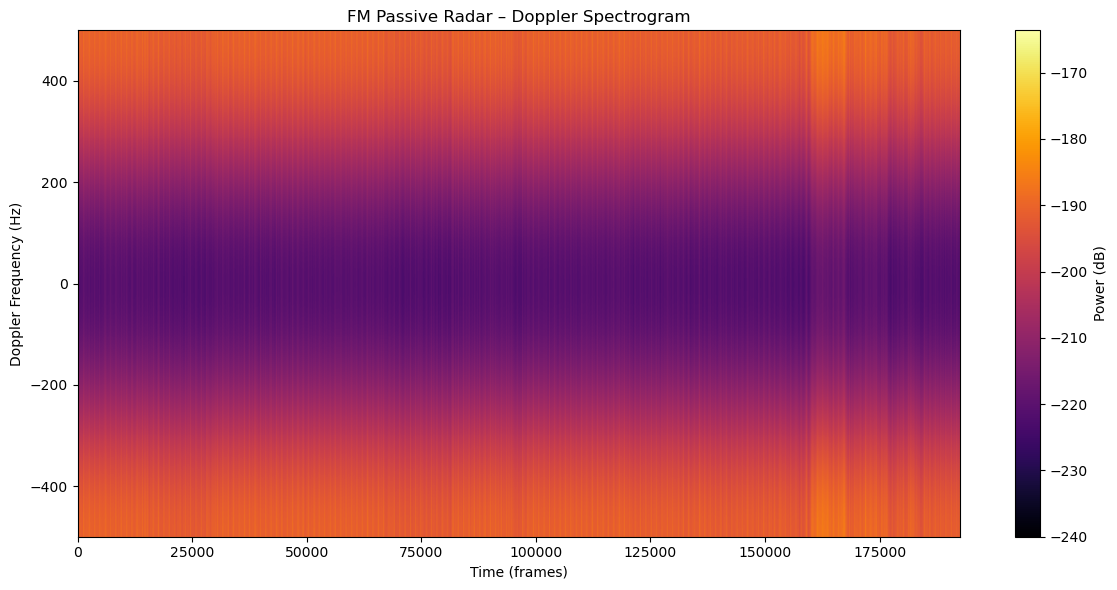

In [31]:
# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 6))
plt.imshow(
    20*np.log10(S + 1e-12),
    aspect="auto",
    origin="lower",
    extent=[0, S.shape[1], f[0], f[-1]],
    cmap="inferno"
)
plt.ylim(-doppler_limit, doppler_limit)
plt.xlabel("Time (frames)")
plt.ylabel("Doppler Frequency (Hz)")
plt.title("FM Passive Radar – Doppler Spectrogram")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()